# 📊 Customer Churn Analysis — Telco Customer Retention Case Study

## 🎯 Business Objective

Customer churn is one of the most important challenges for subscription-based telecom companies. When customers leave, the company loses recurring revenue, customer lifetime value, and future growth opportunities.

The objective of this analysis is to understand customer churn behavior, identify the key factors associated with churn, and provide actionable recommendations that can help the business improve customer retention.

## 📌 Project Overview

This notebook performs an exploratory data analysis of the IBM Telco Customer Churn dataset. The analysis focuses on understanding how customer demographics, contract type, tenure, payment method, monthly charges, and service usage relate to churn behavior.

The goal is not only to explore the dataset, but also to translate data findings into business insights that can support decision-making for customer retention teams.

## 🧠 Key Business Questions

This analysis aims to answer the following questions:

1. What is the overall customer churn rate?
2. Which customer segments have the highest churn risk?
3. How does contract type affect churn behavior?
4. Are newer customers more likely to churn?
5. Which payment methods are associated with higher churn?
6. Do value-added services such as Tech Support and Online Security reduce churn?
7. What actions can the business take to reduce churn?

## 🛠️ Analytical Approach

The notebook follows a structured data analysis workflow:

* Data loading and initial inspection
* Data quality assessment
* Target variable analysis
* Contract-based churn analysis
* Payment method churn analysis
* Tenure-based churn analysis
* Service usage churn analysis
* Business insight extraction
* Actionable recommendations

## ✅ Expected Outcome

By the end of this analysis, we will identify the most important churn drivers and define high-risk customer groups. These insights can be used to design retention campaigns, improve customer onboarding, promote long-term contracts, and increase adoption of value-added services.


In [1]:
# Load the Telco Customer Churn dataset and preview the first few rows
import pandas as pd

df = pd.read_csv("E:/Customer Churn Analysis/data/raw/Telco-Customer-Churn.csv")

df.head()

c:\Users\mahdi\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\mahdi\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check the dimensions of the dataset (number of rows and columns)
df.shape

(7043, 21)

In [3]:
# Display basic information about the dataset including data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# List the names of all columns in the dataset
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
# Generate descriptive statistics for all columns, including non-numeric ones
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Identify missing values across the dataset
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Calculate the proportion of churn (Yes vs No)
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

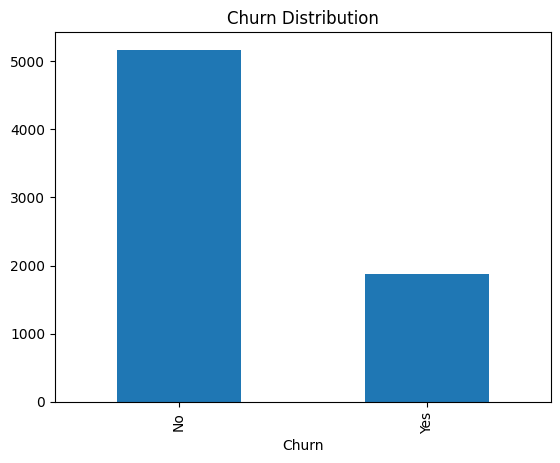

In [8]:
# Plot the distribution of the churn variable to visualize class imbalance
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()

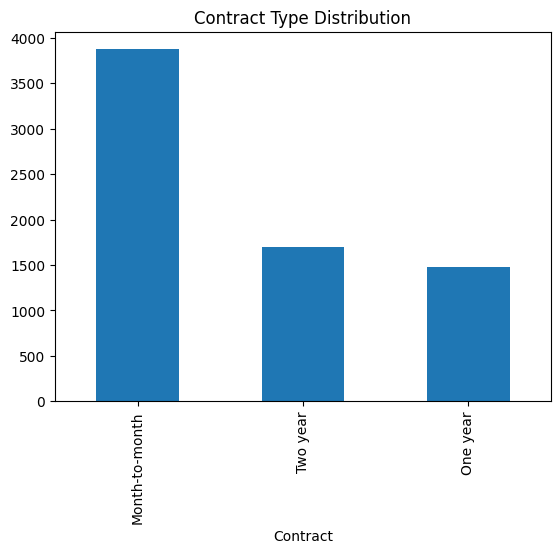

In [9]:
# Plot the distribution of contract types among customers
df["Contract"].value_counts().plot(kind="bar")
plt.title("Contract Type Distribution")
plt.show()

In [10]:
# Calculate the percentage distribution of each contract type
df["Contract"].value_counts(normalize=True) * 100

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

In [11]:
# Compute the churn rate for each contract type
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

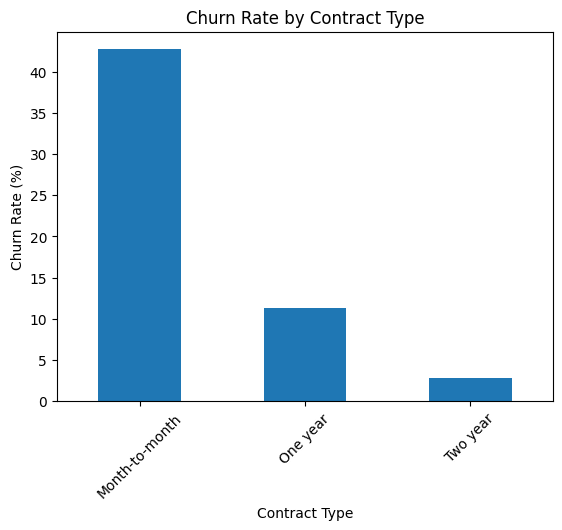

In [12]:
# Visualize the churn rate across different contract types
contract_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [13]:
# Compute churn distribution by payment method
import pandas as pd
import matplotlib.pyplot as plt

payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [14]:
# Calculate the churn rate by payment method
payment_churn_rate = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

payment_churn_rate

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64

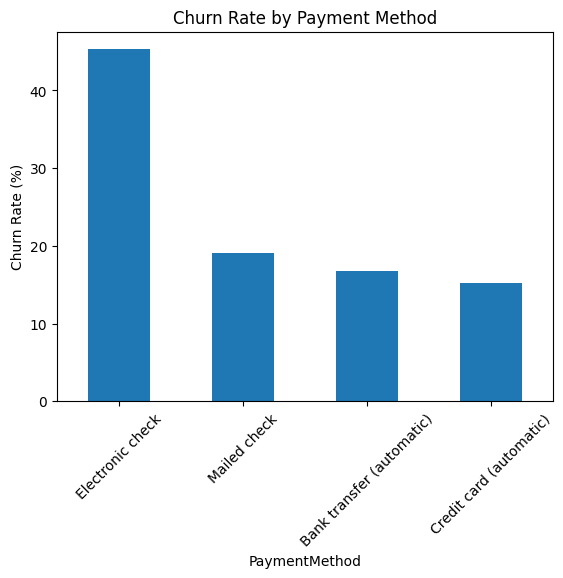

In [15]:
# Visualize the churn rate for each payment method
payment_churn_rate.plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [17]:
# Create tenure groups and compute the churn rate for each group
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1 year", "1-2 years", "2-4 years", "4+ years"]
)

tenure_churn = (
    df.groupby("tenure_group")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

tenure_churn

tenure_group
0-1 year     47.678161
1-2 years    28.710938
2-4 years    20.388959
4+ years      9.513176
Name: Churn, dtype: float64

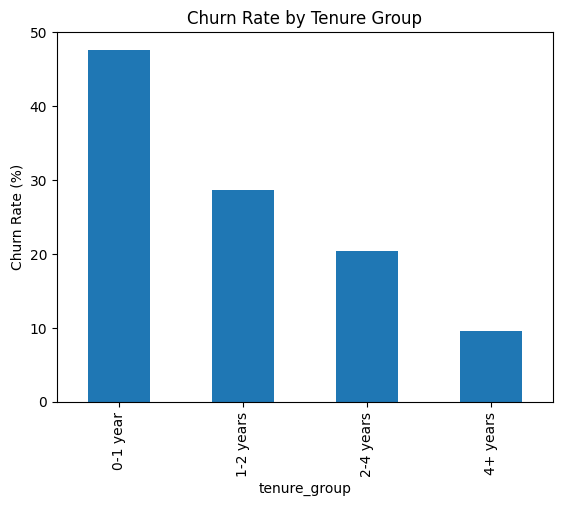

In [18]:
# Plot the churn rate across tenure groups
tenure_churn.plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.show()

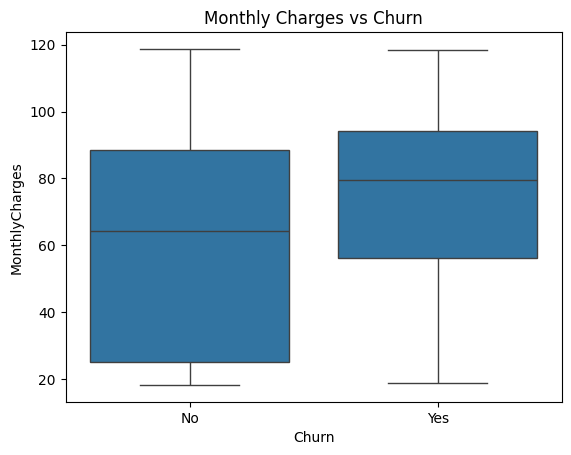

In [19]:
# Visualize the relationship between monthly charges and churn using a boxplot
import seaborn as sns

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [20]:
# Compute the churn rate by internet service type
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

internet_churn

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64

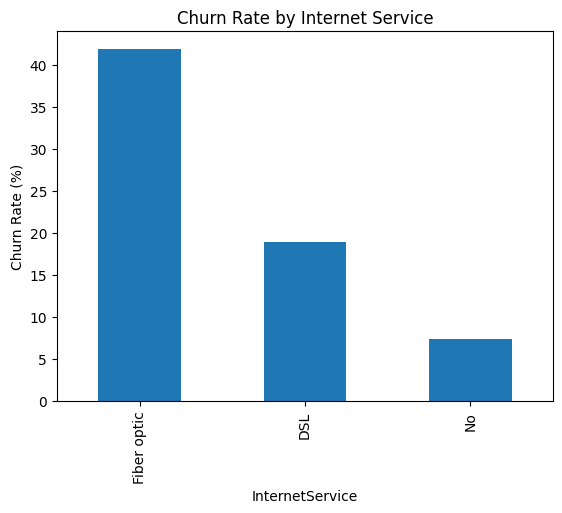

In [21]:
# Visualize churn rate across internet service types
internet_churn.plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

In [22]:
# Compute the churn rate based on availability of Tech Support and Online Security services
cols = ["TechSupport", "OnlineSecurity"]

for col in cols:
    churn_rate = df.groupby(col)["Churn"].apply(lambda x: (x=="Yes").mean()*100)
    print("\n", col)
    print(churn_rate)


 TechSupport
TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Churn, dtype: float64

 OnlineSecurity
OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Churn, dtype: float64
